# Assignement 2

l'objectif de cet assignement est de construire un réseau de neurone à 2 couches.

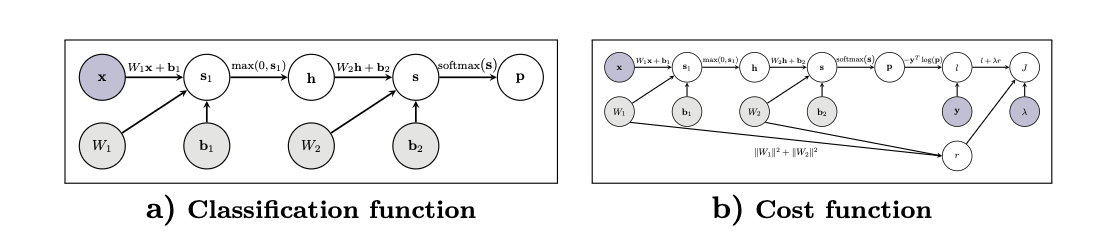

In [1]:
import torch
import matplotlib.pyplot as plt
import pickle
import numpy as np
import os
import copy

In [2]:
# Récupère le dossier où se trouve ton notebook
base_dir = os.getcwd()

## Exercice 1

### 1.1 Read in the data & initialize the parameters of the network

In [3]:
def loadBatch(filename):
    cifar_dir = 'cifar-10-batches-py/'
    with open(cifar_dir + filename, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')

    # Extract the image data and cast to float from the dict dictionary
    X = dict[b'data'].astype(np.float64) / 255.0
    X = X.transpose()
    # one-hot representation of the label for each image
    y = list(dict[b'labels'])
    Y = np.eye(10, dtype=X.dtype)[y].T

    return X, Y, y

loading the data and compute $mean_X$ and $std_X$.

In [4]:
trainX, trainY, train_y = loadBatch("data_batch_1")
valX, valY, val_y = loadBatch("data_batch_2")
testX, testY, test_y = loadBatch("test_batch")

d, n = trainX.shape
mean_trainX = np.mean(trainX, axis=1).reshape(d, 1)
std_trainX = np.std(trainX, axis=1).reshape(d, 1)


## normalisation ##

trainX = (trainX - mean_trainX) / std_trainX
valX = (valX - mean_trainX) / std_trainX
testX = (testX - mean_trainX) / std_trainX


/var/folders/p5/q_svw6p15zg9rpq42m98_sf40000gn/T/ipykernel_94403/2923868985.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


### 1.2 Initialization du réseau

In [5]:
L = 2 ## this assignement is a network of 2 layers
net_params = {}
net_params['W'] = [None] * L
net_params['b'] = [None] * L

In [6]:
def random_assignment_L_layers(network,L):
    """
    permet de pouvoir initier des points de manière randoms en gardant un certain range
    """
    for i in range(L):
        rng = np.random.default_rng()
        # get the BitGenerator used by default_rng
        BitGen = type(rng.bit_generator)
        # use the state from a fresh bit generator
        seed = 42
        rng.bit_generator.state = BitGen(seed).state
        network['W'][i] = .01*rng.standard_normal(size = network['W'][i].shape)
        network['b'][i] = np.zeros(network['b'][i].shape)

## Exercice 2

Dans cette partie de code, nous allons recoder les fonctions qui calucles le gradient pour pouvoir acceuillir maintenant un réseau de neurone de 2 couches.

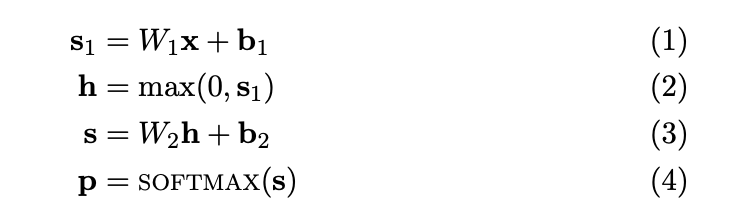

In [7]:
def softMax(s):
    s_shift = s - np.max(s, axis=0, keepdims=True)
    exp_s = np.exp(s_shift)
    return exp_s / np.sum(exp_s, axis=0, keepdims=True)
    
def ApplyNetwork(X, network):
    fp_data = {}
    s1 = network['W'][0] @ X + network['b'][0]
    h = np.maximum(0, s1)
    s = network['W'][1] @ h + network['b'][1]
    p = softMax(s)

    fp_data['s1'] = s1
    fp_data['h'] = h
    fp_data['s'] = s
    fp_data['p'] = p
    
    return fp_data

## 2.2 Compute the cost function

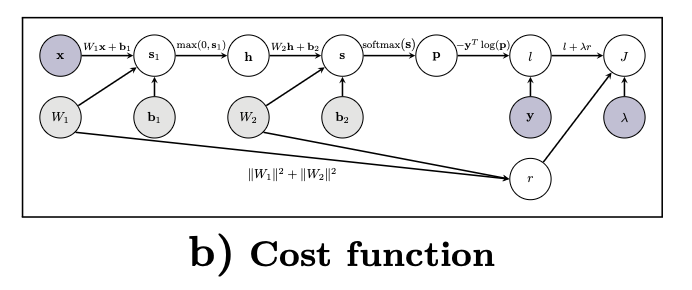

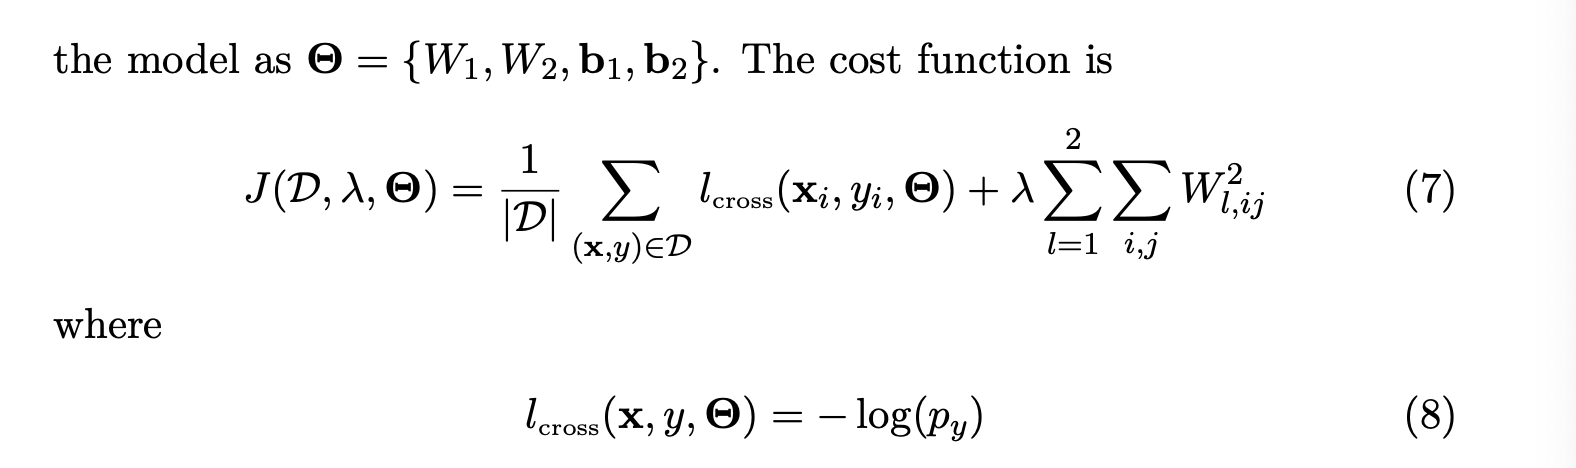

In [8]:
## 2.2.1 compute loss
def ComputeLoss(P, y):
    y = np.array(y)
    N = P.shape[1]
    return -np.mean(np.log(P[y, np.arange(N)]))

def ComputeCost(P, y, network, lam):
    loss = ComputeLoss(P, y)
    reg = lam * sum(np.sum(W**2) for W in network['W'])
    return reg + loss

## 2.3 Compute the Gradient

Nous allons exploter les formules du bas suivante pour calculer le gradient des poids et de b.

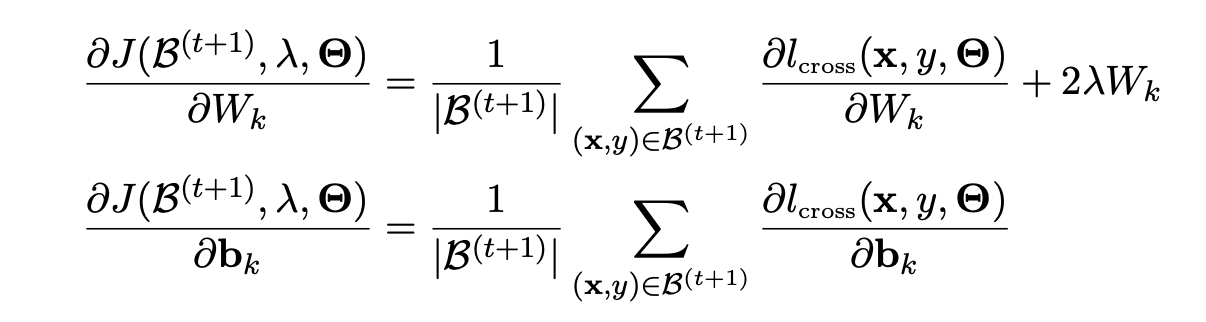

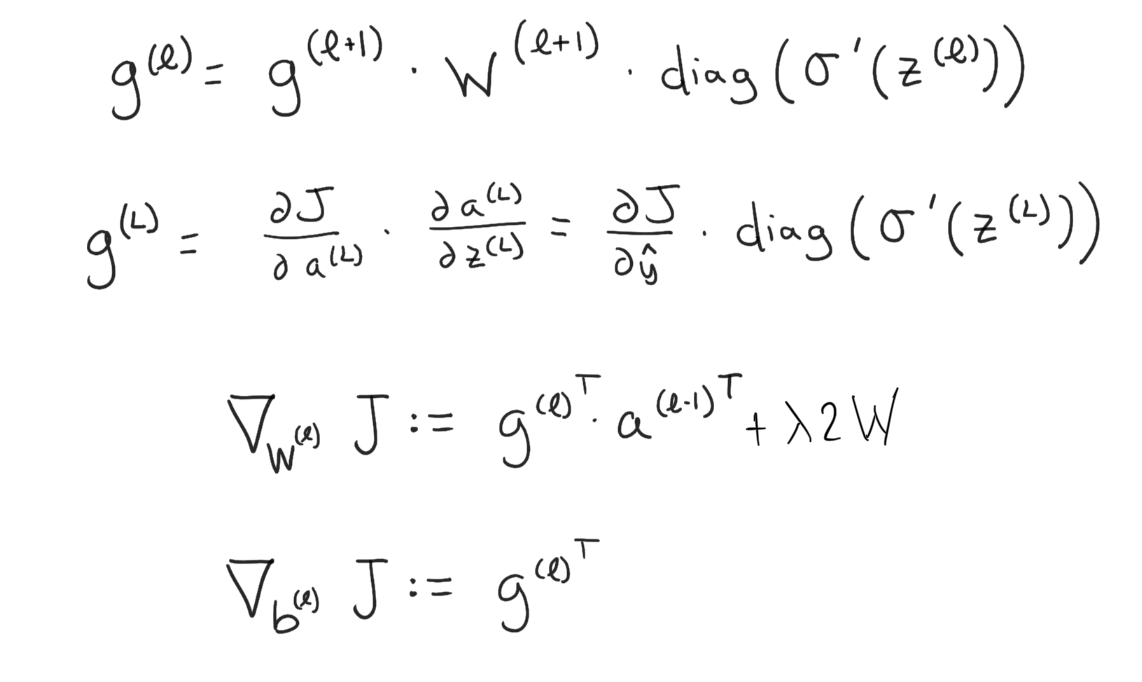

| Maths | Mon code |
|------|--------|
| $a^{(l)}$ | `h` |
| $z^{(l)}$ | `s` |
| $g^{(l)}$ ou $g^{(L)}$ | `G` |
| $W^{(l)}$ | `network['W'][l]` |

dans le code si dessous, pour bien comprendre ce qu'il se passe voici une petit légende:



In [9]:
def BackwardPass(X, Y, fp_data, network, lam):
    N = X.shape[1]
    grads = {'W': [None] * 2, 'b': [None] * 2}
    h = fp_data['h']
    s1 = fp_data['s1']
    P = fp_data['p']

    G = P - Y

    grads['W'][1] = (G @ h.T) / N + 2 * lam * network['W'][1]
    grads['b'][1] = np.sum(G, axis=1, keepdims=True) / N

    G = network['W'][1].T @ G
    G = G * (s1 > 0) # --> chain rule avec la fonction d activation RelU.

    grads['W'][0] = (G @ X.T) / N + 2 * lam * network['W'][0]
    grads['b'][0] = np.sum(G, axis=1, keepdims=True) / N

    return grads

## REMARK: pourquoi on peut G = P-Y

Gradient de la loss softmax + cross-entropy

On a :

$p_k = \frac{e^{s_k}}{\sum_j e^{s_j}}, \quad$
$J = -\sum_k y_k \log p_k$

Par règle de chaîne :

$\frac{\partial J}{\partial s_k}= \sum_j \frac{\partial J}{\partial p_j} \frac{\partial p_j}{\partial s_k}$

Or :

$\frac{\partial J}{\partial p_j} = -\frac{y_j}{p_j}$

et pour le softmax :

$\frac{\partial p_j}{\partial s_k}=p_j(\delta_{jk} - p_k)$

Donc :

$\frac{\partial J}{\partial s_k}= \sum_j \left(-\frac{y_j}{p_j}\right) p_j(\delta_{jk} - p_k)= \sum_j -y_j(\delta_{jk} - p_k) = - y_k + p_k \sum_j y_j$

Comme $\sum_j y_j = 1$ (one-hot) :

$\frac{\partial J}{\partial s_k} = p_k - y_k$


Résultat final

$\boxed{\frac{\partial J}{\partial s} = P - Y}$

Cette logique est la même pour le résultat de G = G * (s1 > 0)

## Vérification de notre implémentation ( utiliser le code torch )

In [10]:
def ComputeGradsWithTorch(X, y, network_params):
    
    Xt = torch.from_numpy(X)

    L = len(network_params['W'])

    # will be computing the gradient w.r.t. these parameters    
    W = [None] * L
    b = [None] * L    
    for i in range(len(network_params['W'])):
        W[i] = torch.tensor(network_params['W'][i], requires_grad=True)
        b[i] = torch.tensor(network_params['b'][i], requires_grad=True)        

    ## give informative names to these torch classes        
    apply_relu = torch.nn.ReLU()
    apply_softmax = torch.nn.Softmax(dim=0)

    #### BEGIN your code ###########################
    
    # Apply the scoring function corresponding to equations (1-3) in assignment description 
    # If X is d x n then the final scores torch array should have size 10 x n
    
    s1 = W[0] @ Xt + b[0]
    h = apply_relu(s1)
    scores = W[1] @ h + b[1]

    #### END of your code ###########################            

    # apply SoftMax to each column of scores     
    P = apply_softmax(scores)
    
    # compute the loss
    n = X.shape[1]
    loss = torch.mean(-torch.log(P[y, np.arange(n)]))
    
    # compute the backward pass relative to the loss and the named parameters 
    loss.backward()

    # extract the computed gradients and make them numpy arrays 
    grads = {}
    grads['W'] = [None] * L
    grads['b'] = [None] * L
    for i in range(L):
        grads['W'][i] = W[i].grad.numpy()
        grads['b'][i] = b[i].grad.numpy()

    return grads


### test pour comparer si les résultats sont cohérants entre les deux implémentation

In [11]:
### TEST ###
L = 2 ## this assignement is a network of 2 layers
small_net = {}
small_net['W'] = [None] * L
small_net['b'] = [None] * L
rng = np.random.default_rng(seed=0)
d_small = 5
n_small = 3
m = 6
lam = 0
small_net['W'][0] = (1/np.sqrt(d_small))*rng.standard_normal(size = (m, d_small))
small_net['b'][0] = np.zeros((m, 1))
small_net['W'][1] = (1/np.sqrt(m))*rng.standard_normal(size = (10, m))
small_net['b'][1] = np.zeros((10, 1))
X_small = trainX[0:d_small, 0:n_small]
Y_small = trainY[:, 0:n_small]
fp_data = ApplyNetwork(X_small, small_net)
my_grads = BackwardPass(X_small, Y_small, fp_data, small_net, lam)
torch_grads = ComputeGradsWithTorch(X_small, train_y[0:n_small], small_net)

eps = 1e-6

res_W = []
res_b = []

for l in range(len(my_grads['W'])):
    w_diff = np.abs(my_grads['W'][l] - torch_grads['W'][l]) / np.maximum(
        eps,
        np.abs(my_grads['W'][l]) + np.abs(torch_grads['W'][l])
    )
    res_W.append(np.max(w_diff))

    b_diff = np.abs(my_grads['b'][l] - torch_grads['b'][l]) / np.maximum(
        eps,
        np.abs(my_grads['b'][l]) + np.abs(torch_grads['b'][l])
    )
    res_b.append(np.max(b_diff))

print("TEST Gradient between my code and pytorch")
for l in range(len(res_W)):
    print(f"Layer {l}: max relative error W = {res_W[l]}")
    print(f"Layer {l}: max relative error b = {res_b[l]}")
print(" ==============================================")

TEST Gradient between my code and pytorch
Layer 0: max relative error W = 1.657081376524927e-15
Layer 0: max relative error b = 3.1173445742970384e-16
Layer 1: max relative error W = 1.7482943608370442e-16
Layer 1: max relative error b = 1.2798591396171805e-16


## Check By training a Network
Nous allons vérifier si toute les fonctions codées jusque là pour le résueax de neurone a 2 couches et correct. pour ce faire nous allons simplement exploiter un training data de 100exemples avec une régularization de zéor $lam$ = 0 

In [12]:
import numpy as np
import copy

def miniBatchGD(X, Y, y, valX, val_y, GDparams, init_net, seed):
    trained_net = copy.deepcopy(init_net)

    n_batch = GDparams['n_batch']
    eta = GDparams['eta']
    n_epochs = GDparams['n_epochs']
    lam = GDparams['lam']

    n = X.shape[1]
    rng = np.random.default_rng(seed)

    train_losses = []
    val_losses = []
    train_costs = []
    val_costs = []

    for epoch in range(n_epochs):
        perm = rng.permutation(n)
        X_shuffled = X[:, perm]
        Y_shuffled = Y[:, perm]

        for j in range(n // n_batch):
            j_start = j * n_batch
            j_end = (j + 1) * n_batch

            Xbatch = X_shuffled[:, j_start:j_end]
            Ybatch = Y_shuffled[:, j_start:j_end]

            #foward
            fp_data = ApplyNetwork(Xbatch, trained_net)

            # Backprop
            grads = BackwardPass(Xbatch, Ybatch, fp_data, trained_net, lam)

            # Update couche par couche
            for l in range(len(trained_net['W'])):
                trained_net['W'][l] -= eta * grads['W'][l]
                trained_net['b'][l] -= eta * grads['b'][l]

        # ----- Evaluation -----
        fp_data_train = {}
        fp_data_train = ApplyNetwork(X, trained_net)
        trainP = fp_data_train['p']

        fp_data_val = ApplyNetwork(valX, trained_net)
        valP = fp_data_val['p']

        train_loss = ComputeLoss(trainP, y)
        val_loss = ComputeLoss(valP, val_y)

        train_cost = ComputeCost(trainP, y, trained_net, lam)
        val_cost = ComputeCost(valP, val_y, trained_net, lam)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_costs.append(train_cost)
        val_costs.append(val_cost)

        print(f"Epoch {epoch+1}/{n_epochs}: train loss = {train_loss:.6f}, val loss = {val_loss:.6f}")

    history = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_cost': train_costs,
        'val_cost': val_costs,
    }

    return trained_net, history

In [33]:
## initalisation ##
GDparams = {}
GDparams['n_batch'] = 100
GDparams['eta'] = .001
GDparams['n_epochs'] = 40 ## nombre de fois que je vais traverser les n_batch
GDparams['lam'] = 0.1
L = 2 ## this assignement is a network of 2 layers
seed = 42
init_net = {}
init_net['W'] = [None] * L
init_net['b'] = [None] * L
rng = np.random.default_rng(seed=0)
m = 50 ## demandé au début du document
lam = 0
d = trainX.shape[0]
init_net['W'][0] = (1/np.sqrt(d_small))*rng.standard_normal(size = (m, d))
init_net['b'][0] = np.zeros((m, 1))
init_net['W'][1] = (1/np.sqrt(m))*rng.standard_normal(size = (10, m))
init_net['b'][1] = np.zeros((10, 1))

## TRAINING ##

trained_net, history = miniBatchGD(trainX, trainY, train_y, valX, val_y, GDparams, init_net, seed)

Epoch 1/40: train loss = 10.289070, val loss = 5.839336
Epoch 2/40: train loss = 7.102000, val loss = 4.558033
Epoch 3/40: train loss = 5.180718, val loss = 3.479848
Epoch 4/40: train loss = 3.893397, val loss = 2.757089
Epoch 5/40: train loss = 3.041343, val loss = 2.506238
Epoch 6/40: train loss = 2.514478, val loss = 2.292674
Epoch 7/40: train loss = 2.228650, val loss = 2.251495
Epoch 8/40: train loss = 2.076630, val loss = 2.210031
Epoch 9/40: train loss = 1.993885, val loss = 2.213178
Epoch 10/40: train loss = 1.959345, val loss = 2.197008
Epoch 11/40: train loss = 1.940605, val loss = 2.190326
Epoch 12/40: train loss = 1.926554, val loss = 2.180167
Epoch 13/40: train loss = 1.916656, val loss = 2.204963
Epoch 14/40: train loss = 1.911763, val loss = 2.185121
Epoch 15/40: train loss = 1.914821, val loss = 2.179782
Epoch 16/40: train loss = 1.908611, val loss = 2.192078
Epoch 17/40: train loss = 1.902796, val loss = 2.203093
Epoch 18/40: train loss = 1.903534, val loss = 2.194949


After training the network on 100 samples with no regularization, we verify the sanity check by evaluating the training loss and accuracy on the same 100 examples. If the implementation is correct, the network should be able to overfit this small dataset, leading to a very low training loss ( so each epoch should reduce and it is actually the case).

## 3. Train your network with cyclical learning rates

l'objectif est d'adapté $n$ afin que l'entrainement soit plus optimisé. Ci dessous sont les équations qui permettent d'update notre $n$ afin d'optimiser l'apprentissage.

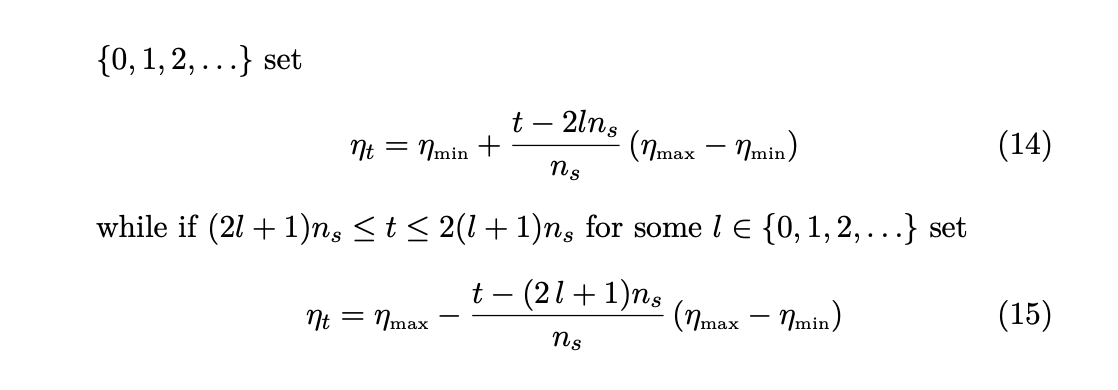

In [34]:
import numpy as np
import copy

def BatchGD_cyclical_learning_rates(X, Y, y, valX, valY, val_y,
                                    init_net, lam, seed,n_s = 500, n_cycles = 1):
    trained_net = copy.deepcopy(init_net)

    eta_min = 1e-5
    eta_max = 1e-1
    n_batch = 100

    n = X.shape[1]
    rng = np.random.default_rng(seed)

    train_losses = []
    val_losses = []
    train_costs = []
    val_costs = []
    train_accs = []
    val_accs = []
    steps = []

    t = 1
    t_max = 2 * n_s * n_cycles

    # comme dans la figure 3 : environ 10 mesures par cycle
    eval_every = max(1, t_max // 10)

    while t < t_max:
        perm = rng.permutation(n)
        X_shuffled = X[:, perm]
        Y_shuffled = Y[:, perm]

        for j in range(n // n_batch):
            if t >= t_max:
                break

            j_start = j * n_batch
            j_end = (j + 1) * n_batch

            Xbatch = X_shuffled[:, j_start:j_end]
            Ybatch = Y_shuffled[:, j_start:j_end]

            fp_data = ApplyNetwork(Xbatch, trained_net)
            grads = BackwardPass(Xbatch, Ybatch, fp_data, trained_net, lam)

            l_cycle = t // (2 * n_s)

            if 2 * l_cycle * n_s <= t <= (2 * l_cycle + 1) * n_s:
                eta = eta_min + (t - 2 * l_cycle * n_s) / n_s * (eta_max - eta_min)
            else:
                eta = eta_max - (t - (2 * l_cycle + 1) * n_s) / n_s * (eta_max - eta_min)

            for layer in range(len(trained_net['W'])):
                trained_net['W'][layer] -= eta * grads['W'][layer]
                trained_net['b'][layer] -= eta * grads['b'][layer]

            t += 1
            # on n'évalue pas à chaque update pour garder des courbes plus lisses
            if (t % eval_every == 0) or (t == t_max):
                trainP = ApplyNetwork(X, trained_net)['p']
                valP = ApplyNetwork(valX, trained_net)['p']

                train_loss = ComputeLoss(trainP, y)
                val_loss = ComputeLoss(valP, val_y)

                train_cost = ComputeCost(trainP, y, trained_net, lam)
                val_cost = ComputeCost(valP, val_y, trained_net, lam)

                train_acc = ComputeAccuracy(trainP, y)
                val_acc = ComputeAccuracy(valP, val_y)

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                train_costs.append(train_cost)
                val_costs.append(val_cost)
                train_accs.append(train_acc)
                val_accs.append(val_acc)
                steps.append(t)

                print(f"Update {t}/{t_max}: "
                      f"train loss = {train_loss:.6f}, val loss = {val_loss:.6f}, "
                      f"train acc = {train_acc:.4f}, val acc = {val_acc:.4f}")


    history = {
        'steps': steps,
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_cost': train_costs,
        'val_cost': val_costs,
        'train_acc': train_accs,
        'val_acc' : val_accs
    }

    return trained_net, history

### fonction pour calculer l'accuracy

In [35]:
def ComputeAccuracy(P, y):
    pred = np.argmax(P, axis=0)
    y = np.array(y)
    return np.mean(pred == y)

### plots training curves

In [36]:
def PlotTrainingCurves(history):
    steps = history['steps']

    plt.figure(figsize=(18, 5))

    # Cost
    plt.subplot(1, 3, 1)
    plt.plot(steps, history['train_cost'], label='training')
    plt.plot(steps, history['val_cost'], label='validation')
    plt.xlabel('update step')
    plt.ylabel('cost')
    plt.title('Cost plot', fontsize=18, fontweight='bold')
    plt.legend()

    # Loss
    plt.subplot(1, 3, 2)
    plt.plot(steps, history['train_loss'], label='training')
    plt.plot(steps, history['val_loss'], label='validation')
    plt.xlabel('update step')
    plt.ylabel('loss')
    plt.title('Loss plot', fontsize=18, fontweight='bold')
    plt.legend()

    # Accuracy
    plt.subplot(1, 3, 3)
    plt.plot(steps, history['train_acc'], label='training')
    plt.plot(steps, history['val_acc'], label='validation')
    plt.xlabel('update step')
    plt.ylabel('accuracy')
    plt.title('Accuracy plot', fontsize=18, fontweight='bold')
    plt.legend()

    plt.tight_layout()
    plt.show()

### Test final exercice 3

Update 100/1000: train loss = 1.831644, val loss = 2.142451, train acc = 0.3623, val acc = 0.2101
Update 200/1000: train loss = 1.659657, val loss = 2.124530, train acc = 0.4149, val acc = 0.2216
Update 300/1000: train loss = 1.563224, val loss = 2.089764, train acc = 0.4593, val acc = 0.2518
Update 400/1000: train loss = 1.524599, val loss = 2.154473, train acc = 0.4683, val acc = 0.2047
Update 500/1000: train loss = 1.439731, val loss = 2.133134, train acc = 0.5027, val acc = 0.2192
Update 600/1000: train loss = 1.376728, val loss = 2.046002, train acc = 0.5229, val acc = 0.2867
Update 700/1000: train loss = 1.313733, val loss = 2.054374, train acc = 0.5568, val acc = 0.2610
Update 800/1000: train loss = 1.261689, val loss = 2.005353, train acc = 0.5774, val acc = 0.2693
Update 900/1000: train loss = 1.209410, val loss = 2.012463, train acc = 0.5947, val acc = 0.3055
Update 1000/1000: train loss = 1.187413, val loss = 2.004743, train acc = 0.6052, val acc = 0.2870


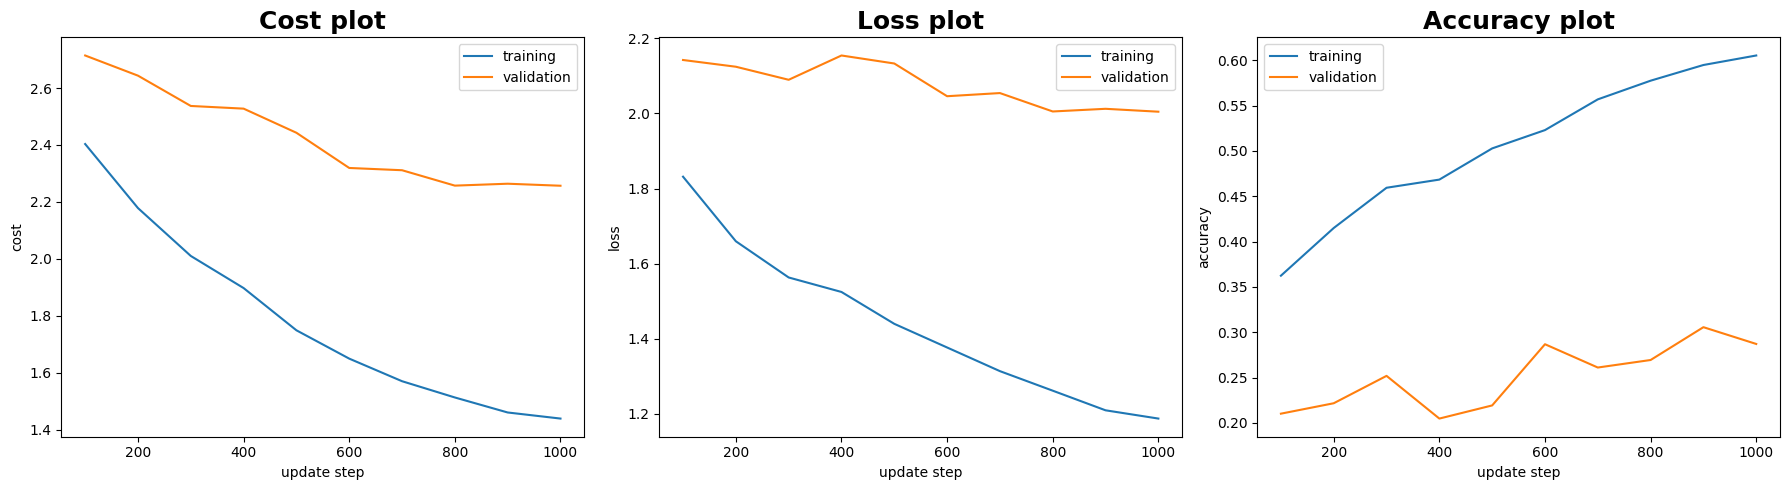

Final test accuracy: 29.48%


In [44]:
lam = 0.01
seed = 0
rng = np.random.default_rng(seed=0)
m = 50
d = trainX.shape[0]

init_net = {}
init_net['W'] = [None] * 2
init_net['b'] = [None] * 2

init_net['W'][0] = (1/np.sqrt(d)) * rng.standard_normal(size=(m, d))
init_net['b'][0] = np.zeros((m, 1))
init_net['W'][1] = (1/np.sqrt(m)) * rng.standard_normal(size=(10, m))
init_net['b'][1] = np.zeros((10, 1))

trained_net, history = BatchGD_cyclical_learning_rates(
    X=trainX,
    Y=trainY,
    y=train_y,
    valX=valX,
    valY=valY,
    val_y=val_y,
    init_net=init_net,
    lam=lam,
    seed=seed
)
fp_data = ApplyNetwork(testX,trained_net)
test_acc = ComputeAccuracy(fp_data['p'], test_y)

PlotTrainingCurves(history)


print(f"Final test accuracy: {100 * test_acc:.2f}%")

The training curves obtained with cyclical learning rates match the expected behavior shown in Figure 3. The loss and cost decrease smoothly while the accuracy increases over time. The validation accuracy reaches approximately 46.47%, which is consistent with the reference result of 46.29%.

## Exercice 4: 

Nous allons tester avec n_s= 800 et cycles = 3

Update 480/4800: train loss = 1.484860, val loss = 1.706108, train acc = 0.4873, val acc = 0.3962
Update 960/4800: train loss = 1.325633, val loss = 1.645253, train acc = 0.5472, val acc = 0.4295
Update 1440/4800: train loss = 1.110903, val loss = 1.565757, train acc = 0.6347, val acc = 0.4554
Update 1920/4800: train loss = 1.137504, val loss = 1.634251, train acc = 0.6110, val acc = 0.4342
Update 2400/4800: train loss = 1.233319, val loss = 1.648446, train acc = 0.5740, val acc = 0.4312
Update 2880/4800: train loss = 1.054582, val loss = 1.574807, train acc = 0.6565, val acc = 0.4552
Update 3360/4800: train loss = 0.982618, val loss = 1.560690, train acc = 0.6934, val acc = 0.4618
Update 3840/4800: train loss = 1.248400, val loss = 1.757185, train acc = 0.5695, val acc = 0.4011
Update 4320/4800: train loss = 1.078259, val loss = 1.604793, train acc = 0.6379, val acc = 0.4513
Update 4800/4800: train loss = 0.929212, val loss = 1.540449, train acc = 0.7212, val acc = 0.4714


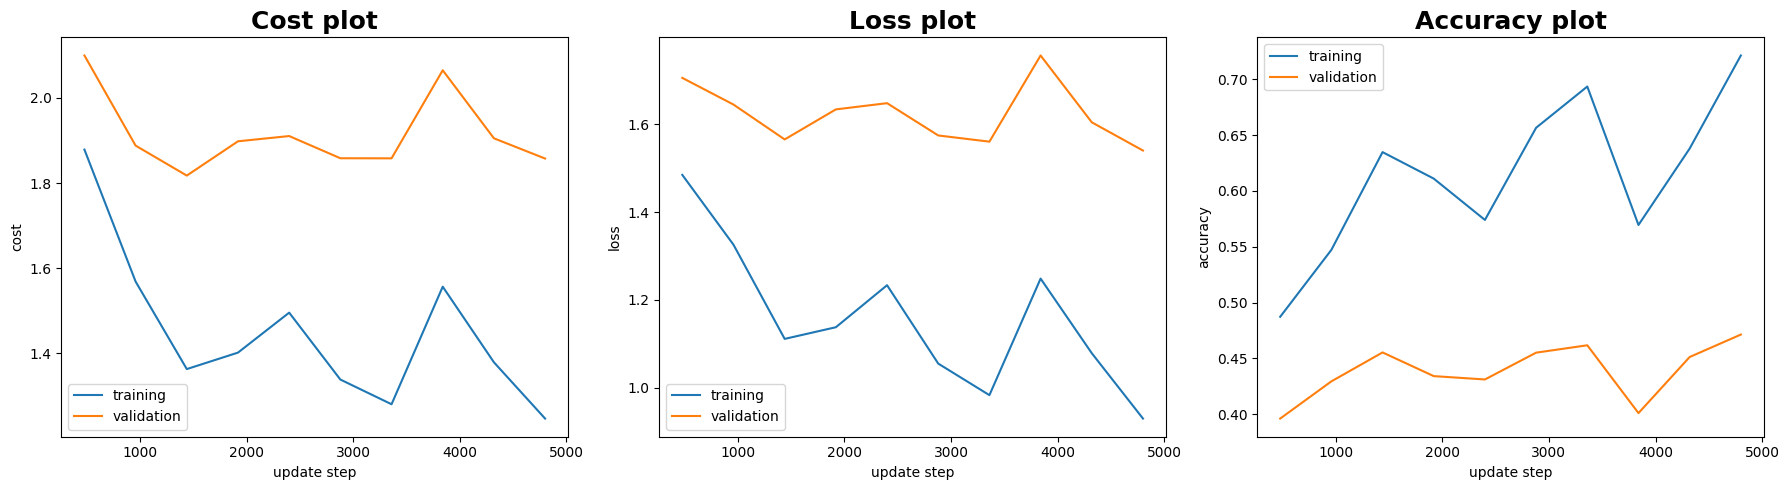

Final test accuracy: 48.00%


In [18]:
lam = 0.01
seed = 0
rng = np.random.default_rng(seed=0)
m = 50
d = trainX.shape[0]


init_net = {}
init_net['W'] = [None] * 2
init_net['b'] = [None] * 2

init_net['W'][0] = (1/np.sqrt(d)) * rng.standard_normal(size=(m, d))
init_net['b'][0] = np.zeros((m, 1))
init_net['W'][1] = (1/np.sqrt(m)) * rng.standard_normal(size=(10, m))
init_net['b'][1] = np.zeros((10, 1))

trained_net, history = BatchGD_cyclical_learning_rates(
    X=trainX,
    Y=trainY,
    y=train_y,
    valX=valX,
    valY=valY,
    val_y=val_y,
    GDparams=GDparams,
    init_net=init_net,
    lam=lam,
    seed=seed,
    n_s = 800, 
    n_cycles = 3
)


fp_data = ApplyNetwork(testX,trained_net)
test_acc = ComputeAccuracy(fp_data['p'], test_y)

PlotTrainingCurves(history)


print(f"Final test accuracy: {100 * test_acc:.2f}%")

# Exercice 4:

In [39]:
def initalize_net(seed):
    rng = np.random.default_rng(seed)
    init_net = {}
    init_net['W'] = [None] * 2
    init_net['b'] = [None] * 2
    
    init_net['W'][0] = (1/np.sqrt(d)) * rng.standard_normal(size=(m, d))
    init_net['b'][0] = np.zeros((m, 1))
    init_net['W'][1] = (1/np.sqrt(m)) * rng.standard_normal(size=(10, m))
    init_net['b'][1] = np.zeros((10, 1))
    return init_net

## 4.1  first perform a coarse search over a very broad range of values for lam. 

In [40]:
## load all the data as it is asked ##
trainX1, trainY1, train_y1 = loadBatch("data_batch_1")
trainX2, trainY2, train_y2 = loadBatch("data_batch_2")
trainX3, trainY3, train_y3 = loadBatch("data_batch_3")
trainX4, trainY4, train_y4 = loadBatch("data_batch_4")
valX, valY, val_y = loadBatch("data_batch_5")
testX, testY, test_y = loadBatch("test_batch")

/var/folders/p5/q_svw6p15zg9rpq42m98_sf40000gn/T/ipykernel_94403/2923868985.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [42]:
## looking the best lam for training ##
def search_best_lam_training(l_max, l_min):
    seed = 42
    rng = np.random.default_rng(seed)
    results = []

    for _ in range(8):
        l = l_min + (l_max - l_min) * rng.random()
        lam = 10 ** l

        init_net = initalize_net(seed)
        n_batch = 100
        n = trainX.shape[1]
        n_s = 2 * np.floor(n / n_batch)

        trained_net, history = BatchGD_cyclical_learning_rates(
            X=trainX,
            Y=trainY,
            y=train_y,
            valX=valX,
            valY=valY,
            val_y=val_y,
            init_net=init_net,
            lam=lam,
            seed=seed,
            n_s=n_s,
            n_cycles=3
        )

        fp_data = ApplyNetwork(valX, trained_net)
        val_acc = ComputeAccuracy(fp_data['p'], val_y)

        results.append((l, lam, val_acc))

    return results
            
            
res = search_best_lam_training(-5,-1)
print(res)
        
    




Update 120/1200.0: train loss = 1.714139, val loss = 2.122370, train acc = 0.4049, val acc = 0.2084
Update 240/1200.0: train loss = 1.527749, val loss = 2.139648, train acc = 0.4699, val acc = 0.1820
Update 360/1200.0: train loss = 1.332518, val loss = 2.073052, train acc = 0.5459, val acc = 0.2581
Update 480/1200.0: train loss = 1.317992, val loss = 2.022806, train acc = 0.5456, val acc = 0.2735
Update 600/1200.0: train loss = 1.483975, val loss = 2.226990, train acc = 0.4899, val acc = 0.1854
Update 720/1200.0: train loss = 1.191981, val loss = 2.027146, train acc = 0.5965, val acc = 0.2941
Update 840/1200.0: train loss = 1.128168, val loss = 2.030108, train acc = 0.6193, val acc = 0.2808
Update 960/1200.0: train loss = 1.317130, val loss = 2.465902, train acc = 0.5550, val acc = 0.1179
Update 1080/1200.0: train loss = 1.144095, val loss = 2.063702, train acc = 0.6082, val acc = 0.2689
Update 1200/1200.0: train loss = 0.985059, val loss = 2.006574, train acc = 0.6797, val acc = 0.281